In [2]:
import numpy as np
import pandas as pd
from plotnine import *
from scipy.stats import *

In [8]:
###### Recordemos que el cálculo de cuantiles a para una variable aleatoria X se
###### refiere a resolver para x la ecuación
###### P(X<=x) = c, donde c es un número dado entre 0 y 1.

## Supongamos que X es v.a. exponencial con lambda = 3. Y sea c = 0.367.
## Encuentra x de tal manera que P(X<=x)=0.367

beta = 1/3
expon.ppf(0.367,scale=beta)

np.float64(0.1524282856126536)

In [9]:
mis_cuantiles = np.array([0.367,0.278,0.666,0.856,0.314])
#P(X<=x)=0.367,P(X<=x)=0.278, P(X<=x)=0.666, P(X<=x)=0.856, P(X<=x)=0.314
expon.ppf(mis_cuantiles, scale=beta)

array([0.15242829, 0.10857671, 0.3655381 , 0.64598066, 0.12562588])

In [10]:
### Existen algunos cuantiles que son de mayor interés que otros.
### Los cuartiles: son 3 y son las soluciones a las ecuaciones
### P(X<=x)=0.25, P(X<=x)=0.5, P(X<=x)=0.75

### Los deciles: son 9 y son las soluciones a las ecuaciones
### P(X<=x)=0.1, P(X<=x)=0.2, P(X<=x)=0.3, P(X<=x)=0.4, ..., P(X<=x)=0.9

### Los quintiles: son 4 y son las soluciones a las ecuaciones
### P(X<=x)=0.2, P(X<=x)=0.4, P(X<=x)=0.6, P(X<=x)=0.8

## cuartiles de una exponencial con lambda = 3
expon.ppf([0.25,0.5,0.75],scale=beta)

array([0.09589402, 0.23104906, 0.46209812])

In [11]:
###########################################################
###########################################################
##############     Análisis de tiempo de llegadas
###########################################################
###########################################################

import pandas as pd
import numpy as np
from plotnine import *
from scipy.stats import *

In [12]:
# Leer datos
datos = pd.read_csv("llegadas_restaurante.csv")
datos

,hora,tamano
0,08:10,2
1,08:21,2
2,08:28,2
3,08:56,2
4,09:04,2
...,...,...
57,16:56,2
58,17:20,2
59,17:40,2
60,17:46,2


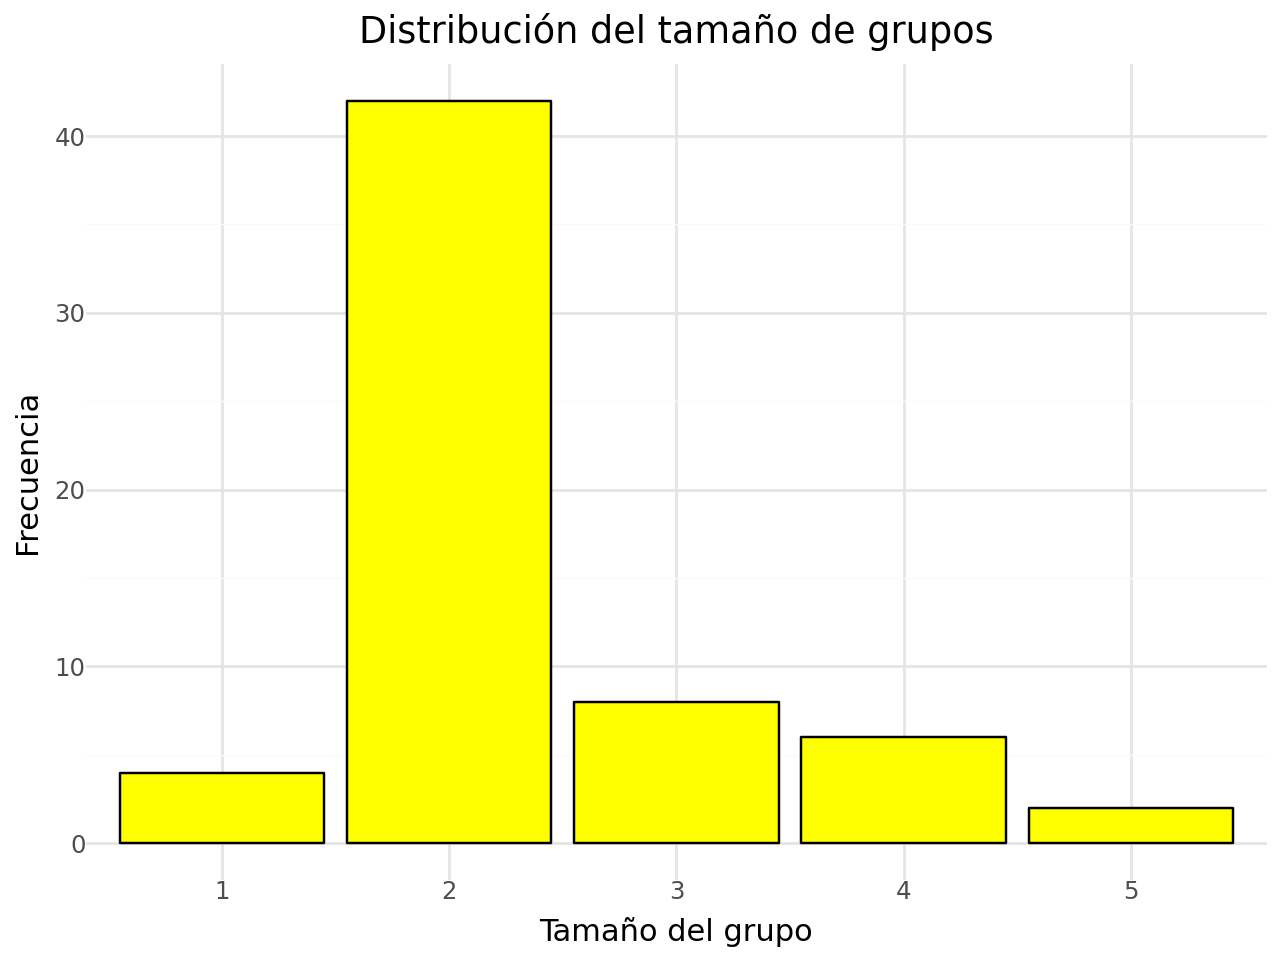

In [13]:

# =====================================================
# Gráfico de barras para el tamaño de los grupos
# =====================================================
(ggplot(datos) +
    geom_bar(aes(x='factor(tamano)'), color="black", fill="yellow") +
    labs(title="Distribución del tamaño de grupos",
         x="Tamaño del grupo",
         y="Frecuencia") +
    theme_minimal()
)


In [14]:
# =====================================================
# Convertir hora y calcular tiempo entre llegadas
# =====================================================
datos['hora'] = pd.to_datetime(datos['hora'], format='%H:%M')

# Ordenar por hora
datos = datos.sort_values('hora').reset_index(drop=True)

# Calcular tiempo entre llegadas en minutos
datos['tiempo_entre_llegadas'] = datos['hora'].diff().dt.total_seconds() / 60
datos = datos.dropna(subset=['tiempo_entre_llegadas']).reset_index(drop=True)

datos

,hora,tamano,tiempo_entre_llegadas
0,1900-01-01 08:21:00,2,11.0
1,1900-01-01 08:28:00,2,7.0
2,1900-01-01 08:56:00,2,28.0
3,1900-01-01 09:04:00,2,8.0
4,1900-01-01 09:05:00,2,1.0
...,...,...,...
56,1900-01-01 16:56:00,2,1.0
57,1900-01-01 17:20:00,2,24.0
58,1900-01-01 17:40:00,2,20.0
59,1900-01-01 17:46:00,2,6.0


In [15]:
# =====================================================
# Resumen estadístico
# =====================================================
print("Resumen estadístico de tiempos entre llegadas:")
print(datos['tiempo_entre_llegadas'].describe())
print(f"\nMedia: {datos['tiempo_entre_llegadas'].mean():.4f}")
print(f"Número de observaciones: {len(datos)}")
print(f"Desviación estándar: {datos['tiempo_entre_llegadas'].std():.4f}")

Resumen estadístico de tiempos entre llegadas:
count    61.000000
mean      9.557377
std       9.802252
min       0.000000
25%       3.000000
50%       7.000000
75%      12.000000
max      55.000000
Name: tiempo_entre_llegadas, dtype: float64

Media: 9.5574
Número de observaciones: 61
Desviación estándar: 9.8023
